# Online Advertising Performance Metrics Analysis

This notebook performs a comprehensive analysis of online advertising campaign performance.
- Calculate key metrics: ROI, CTR, CPC, CPA, ROAS
    - ROI: Return on Investment
    - ROAS: Return on Ad Spend (most critical for e-commerce)
    - CTR: Click-Through Rate
    - CPC: Cost Per Click
    - CPA: Cost Per Acquisition
    - Conversion Rate: Post-click conversions
    - AOV: Average Order Value
- Compare performance across banner sizes, placements, and user engagement levels
- Identify trends and derive actionable insights

## Step 1: Load Libraries and Data

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('online_advertising_performance_data.csv')

print(f'Data shape: {df.shape}')
df.head()

Data shape: (15408, 14)


,month,day,campaign_number,user_engagement,banner,placement,displays,cost,clicks,revenue,post_click_conversions,post_click_sales_amount,Unnamed: 12,Unnamed: 13
0,April,1,camp 1,High,160 x 600,abc,4,0.0060,0,0.0000,0,0.0000,NaN,NaN
1,April,1,camp 1,High,160 x 600,def,20170,26.7824,158,28.9717,23,1972.4602,NaN,NaN
2,April,1,camp 1,High,160 x 600,ghi,14701,27.6304,158,28.9771,78,2497.2636,NaN,NaN
3,April,1,camp 1,High,160 x 600,mno,171259,216.8750,1796,329.4518,617,24625.3234,NaN,NaN
4,April,1,camp 1,Low,160 x 600,def,552,0.0670,1,0.1834,0,0.0000,NaN,NaN


## Step 2: Data Exploration and Cleaning

In [13]:
# Check data types
print('Data Types:')
print(df.dtypes)
print('\n' + '='*50)

# Check missing values
print('\nMissing Values:')
missing = df.isnull().sum()
print(missing[missing > 0])

# Basic statistics
print('\nBasic Statistics:')
print(df.describe())

Data Types:
month                       object
day                          int64
campaign_number             object
user_engagement             object
banner                      object
placement                   object
displays                     int64
cost                       float64
clicks                       int64
revenue                    float64
post_click_conversions       int64
post_click_sales_amount    float64
Unnamed: 12                float64
Unnamed: 13                float64
dtype: object


Missing Values:
placement        413
Unnamed: 12    15408
Unnamed: 13    15408
dtype: int64

Basic Statistics:
                day       displays          cost        clicks       revenue  \
count  15408.000000   15408.000000  15408.000000  15408.000000  15408.000000   
mean      15.518886   15512.573014     11.370262    161.788487     17.929943   
std        8.740909   44392.392890     45.369499    728.276911     96.781834   
min        1.000000       0.000000      0.000000   

In [14]:
# Remove completely empty columns
df = df.dropna(axis=1, how='all')
print(f'Columns after cleaning: {len(df.columns)}')
print(f'Column names: {list(df.columns)}')

Columns after cleaning: 12
Column names: ['month', 'day', 'campaign_number', 'user_engagement', 'banner', 'placement', 'displays', 'cost', 'clicks', 'revenue', 'post_click_conversions', 'post_click_sales_amount']


## Step 3: Calculate Core Performance Metrics (KPIs)

In [15]:
# 1. ROI (Return on Investment) = (Revenue - Cost) / Cost * 100
df['roi'] = np.where(df['cost'] > 0, ((df['revenue'] - df['cost']) / df['cost']) * 100, 0)

# 2. CTR (Click-Through Rate) = Clicks / Displays * 100
df['ctr'] = np.where(df['displays'] > 0, (df['clicks'] / df['displays']) * 100, 0)

# 3. CPC (Cost Per Click) = Cost / Clicks
df['cpc'] = np.where(df['clicks'] > 0, df['cost'] / df['clicks'], 0)

# 4. CPA (Cost Per Action/Conversion) = Cost / Conversions
df['cpa'] = np.where(df['post_click_conversions'] > 0, df['cost'] / df['post_click_conversions'], 0)

# 5. Conversion Rate = Conversions / Clicks * 100
df['conversion_rate'] = np.where(df['clicks'] > 0, (df['post_click_conversions'] / df['clicks']) * 100, 0)

# 6. Average Order Value (AOV) = Sales Amount / Conversions
df['aov'] = np.where(df['post_click_conversions'] > 0, df['post_click_sales_amount'] / df['post_click_conversions'], 0)

# 7. ROAS (Return on Ad Spend) = Sales Amount / Cost
df['roas'] = np.where(df['cost'] > 0, df['post_click_sales_amount'] / df['cost'], 0)

print('- ROI: Return on Investment (%)')
print('- CTR: Click-Through Rate (%)')
print('- CPC: Cost Per Click ($)')
print('- CPA: Cost Per Acquisition ($)')
print('- Conversion Rate: Conversion Rate (%)')
print('- AOV: Average Order Value ($)')
print('- ROAS: Return on Ad Spend')

print('\nMetrics Sample:')
df[['campaign_number', 'banner', 'placement', 'cost', 'revenue', 'roi', 'ctr', 'cpc', 'roas']].head(10)

- ROI: Return on Investment (%)
- CTR: Click-Through Rate (%)
- CPC: Cost Per Click ($)
- CPA: Cost Per Acquisition ($)
- Conversion Rate: Conversion Rate (%)
- AOV: Average Order Value ($)
- ROAS: Return on Ad Spend

Metrics Sample:


,campaign_number,banner,placement,cost,revenue,roi,ctr,cpc,roas
0,camp 1,160 x 600,abc,0.0060,0.0000,-100.000000,0.000000,0.000000,0.000000
1,camp 1,160 x 600,def,26.7824,28.9717,8.174398,0.783342,0.169509,73.647627
2,camp 1,160 x 600,ghi,27.6304,28.9771,4.873979,1.074757,0.174876,90.381015
3,camp 1,160 x 600,mno,216.8750,329.4518,51.908611,1.048704,0.120754,113.546160
4,camp 1,160 x 600,def,0.0670,0.1834,173.731343,0.181159,0.067000,0.000000
5,camp 1,160 x 600,ghi,0.0249,0.0000,-100.000000,0.000000,0.000000,0.000000
6,camp 1,160 x 600,mno,0.4044,1.8347,353.684471,0.447628,0.040440,251.605836
7,camp 1,160 x 600,def,1.8899,0.7338,-61.172549,0.134998,0.472475,53.179745
8,camp 1,160 x 600,ghi,0.9917,1.6512,66.501966,1.551724,0.110189,0.000000
9,camp 1,160 x 600,mno,11.1678,33.9397,203.906768,0.918023,0.060366,58.488655


## Step 4: Overall Campaign Performance Summary

In [16]:
# Handle infinite and extreme values
df_clean = df.replace([np.inf, -np.inf], np.nan)

# Overall campaign statistics
summary = {
    'Total Displays': df['displays'].sum(),
    'Total Clicks': df['clicks'].sum(),
    'Total Cost': df['cost'].sum(),
    'Total Revenue': df['revenue'].sum(),
    'Total Conversions': df['post_click_conversions'].sum(),
    'Total Sales': df['post_click_sales_amount'].sum(),
    'Avg CTR (%)': df_clean['ctr'].mean(),
    'Avg Conversion Rate (%)': df_clean['conversion_rate'].mean(),
    'Avg CPC ($)': df_clean['cpc'].mean(),
    'Avg CPA ($)': df_clean['cpa'].mean(),
    'Overall ROI (%)': ((df['post_click_sales_amount'].sum() - df['cost'].sum()) / df['cost'].sum() * 100),
    'Overall ROAS': df_clean['roas'].mean()
}

summary_df = pd.DataFrame(list(summary.items()), columns=['Metric', 'Value'])
print('='*60)
print('OVERALL CAMPAIGN PERFORMANCE SUMMARY')
print('='*60)
for idx, row in summary_df.iterrows():
    print(f"{row['Metric']:.<40} {row['Value']:>15,.2f}")

OVERALL CAMPAIGN PERFORMANCE SUMMARY
Total Displays..........................  239,017,725.00
Total Clicks............................    2,492,837.00
Total Cost..............................      175,193.00
Total Revenue...........................      276,264.56
Total Conversions.......................      651,768.00
Total Sales.............................   32,715,622.40
Avg CTR (%).............................            0.81
Avg Conversion Rate (%).................           12.50
Avg CPC ($).............................            0.06
Avg CPA ($).............................            0.31
Overall ROI (%).........................       18,574.05
Overall ROAS............................           93.94


## Step 5: Campaign Performance Analysis

In [17]:
# Campaign performance analysis
campaign_performance = df.groupby('campaign_number').agg({
    'displays': 'sum',
    'clicks': 'sum',
    'cost': 'sum',
    'revenue': 'sum',
    'post_click_conversions': 'sum',
    'post_click_sales_amount': 'sum'
}).reset_index()

# Calculate additional metrics
campaign_performance['ctr'] = (campaign_performance['clicks'] / campaign_performance['displays'] * 100).round(2)
campaign_performance['conversion_rate'] = (campaign_performance['post_click_conversions'] / campaign_performance['clicks'] * 100).round(2)
campaign_performance['cpc'] = (campaign_performance['cost'] / campaign_performance['clicks']).round(3)
campaign_performance['cpa'] = (campaign_performance['cost'] / campaign_performance['post_click_conversions']).round(2)
campaign_performance['roas'] = (campaign_performance['post_click_sales_amount'] / campaign_performance['cost']).round(2)
campaign_performance['roi'] = ((campaign_performance['post_click_sales_amount'] - campaign_performance['cost']) / campaign_performance['cost'] * 100).round(2)

print('\n' + '='*100)
print('CAMPAIGN PERFORMANCE COMPARISON')
print('='*100)
print(campaign_performance[['campaign_number', 'cost', 'post_click_sales_amount', 'roi', 'ctr', 'conversion_rate', 'roas']].to_string(index=False))


CAMPAIGN PERFORMANCE COMPARISON
campaign_number        cost  post_click_sales_amount      roi  ctr  conversion_rate   roas
         camp 1 150688.5798             3.101275e+07 20480.69 0.98            44.93 205.81
         camp 2  17037.3496             1.167509e+06  6752.64 1.94             1.56  68.53
         camp 3   7467.0663             5.353672e+05  7069.71 0.40             2.43  71.70


## Step 6: Banner Size Performance Analysis

In [18]:
# Banner performance analysis
banner_performance = df.groupby('banner').agg({
    'displays': 'sum',
    'clicks': 'sum',
    'cost': 'sum',
    'revenue': 'sum',
    'post_click_conversions': 'sum',
    'post_click_sales_amount': 'sum'
}).reset_index()

# Calculate additional metrics
banner_performance['ctr'] = (banner_performance['clicks'] / banner_performance['displays'] * 100).round(2)
banner_performance['conversion_rate'] = (banner_performance['post_click_conversions'] / banner_performance['clicks'] * 100).round(2)
banner_performance['cpc'] = (banner_performance['cost'] / banner_performance['clicks']).round(3)
banner_performance['roas'] = (banner_performance['post_click_sales_amount'] / banner_performance['cost']).round(2)
banner_performance['roi'] = ((banner_performance['post_click_sales_amount'] - banner_performance['cost']) / banner_performance['cost'] * 100).round(2)

# Sort by efficiency
banner_sorted = banner_performance.sort_values('roas', ascending=False)

print('\n' + '='*100)
print('BANNER SIZE PERFORMANCE (Ranked by ROAS)')
print('='*100)
print(banner_sorted[['banner', 'displays', 'ctr', 'conversion_rate', 'cpc', 'roas', 'roi']].to_string(index=False))


BANNER SIZE PERFORMANCE (Ranked by ROAS)
   banner  displays  ctr  conversion_rate   cpc   roas      roi
240 x 400  65783420 1.69            24.24 0.051 240.92 23992.12
580 x 400   7189697 1.68            26.32 0.074 182.02 18101.93
300 x 250  54838409 0.75            29.13 0.086 180.00 17900.35
 728 x 90  76220124 0.75            29.91 0.093 154.52 15351.68
 468 x 60    695126 0.19            42.47 0.149 144.53 14352.92
160 x 600  28783853 0.83            20.36 0.073 137.31 13631.26
 670 x 90   5504972 0.68            28.54 0.103 134.68 13367.93
800 x 250      2124 0.56            25.00 0.233  40.10  3909.53


## Step 7: Placement Performance Analysis

In [19]:
# Placement performance analysis
placement_performance = df.groupby('placement').agg({
    'displays': 'sum',
    'clicks': 'sum',
    'cost': 'sum',
    'revenue': 'sum',
    'post_click_conversions': 'sum',
    'post_click_sales_amount': 'sum'
}).reset_index()

# Calculate additional metrics
placement_performance['ctr'] = (placement_performance['clicks'] / placement_performance['displays'] * 100).round(2)
placement_performance['conversion_rate'] = (placement_performance['post_click_conversions'] / placement_performance['clicks'] * 100).round(2)
placement_performance['cpc'] = (placement_performance['cost'] / placement_performance['clicks']).round(3)
placement_performance['roas'] = (placement_performance['post_click_sales_amount'] / placement_performance['cost']).round(2)
placement_performance['roi'] = ((placement_performance['post_click_sales_amount'] - placement_performance['cost']) / placement_performance['cost'] * 100).round(2)

# Sort by efficiency
placement_sorted = placement_performance.sort_values('roas', ascending=False)

print('\n' + '='*100)
print('PLACEMENT PERFORMANCE (Ranked by ROAS)')
print('='*100)
print(placement_sorted[['placement', 'displays', 'ctr', 'conversion_rate', 'cpc', 'roas', 'roi']].to_string(index=False))


PLACEMENT PERFORMANCE (Ranked by ROAS)
placement  displays  ctr  conversion_rate   cpc   roas      roi
      abc    242142 0.65            52.02 0.080 335.44 33444.41
      jkl   7692732 0.98            27.78 0.048 298.07 29707.19
      ghi  59740415 2.09            27.03 0.050 264.37 26337.05
      mno 143161775 0.69            26.50 0.096 142.77 14177.07
      def  28177492 0.62            16.95 0.081 111.06 11005.74


## Step 8: User Engagement Performance Analysis

In [20]:
# User engagement performance analysis
engagement_performance = df.groupby('user_engagement').agg({
    'displays': 'sum',
    'clicks': 'sum',
    'cost': 'sum',
    'revenue': 'sum',
    'post_click_conversions': 'sum',
    'post_click_sales_amount': 'sum'
}).reset_index()

# Calculate additional metrics
engagement_performance['ctr'] = (engagement_performance['clicks'] / engagement_performance['displays'] * 100).round(2)
engagement_performance['conversion_rate'] = (engagement_performance['post_click_conversions'] / engagement_performance['clicks'] * 100).round(2)
engagement_performance['cpc'] = (engagement_performance['cost'] / engagement_performance['clicks']).round(3)
engagement_performance['roas'] = (engagement_performance['post_click_sales_amount'] / engagement_performance['cost']).round(2)
engagement_performance['roi'] = ((engagement_performance['post_click_sales_amount'] - engagement_performance['cost']) / engagement_performance['cost'] * 100).round(2)

print('\n' + '='*100)
print('USER ENGAGEMENT PERFORMANCE ANALYSIS')
print('='*100)
print(engagement_performance[['user_engagement', 'displays', 'ctr', 'conversion_rate', 'cpc', 'roas', 'roi']].to_string(index=False))


USER ENGAGEMENT PERFORMANCE ANALYSIS
user_engagement  displays  ctr  conversion_rate   cpc   roas      roi
           High 141977300 0.93            47.13 0.111 207.64 20664.22
            Low  21506999 0.47             1.56 0.026  40.37  3937.43
         Medium  75533426 1.42             2.73 0.024  82.69  8168.81


## Step 9: Visualization - Banner Size Performance Comparison

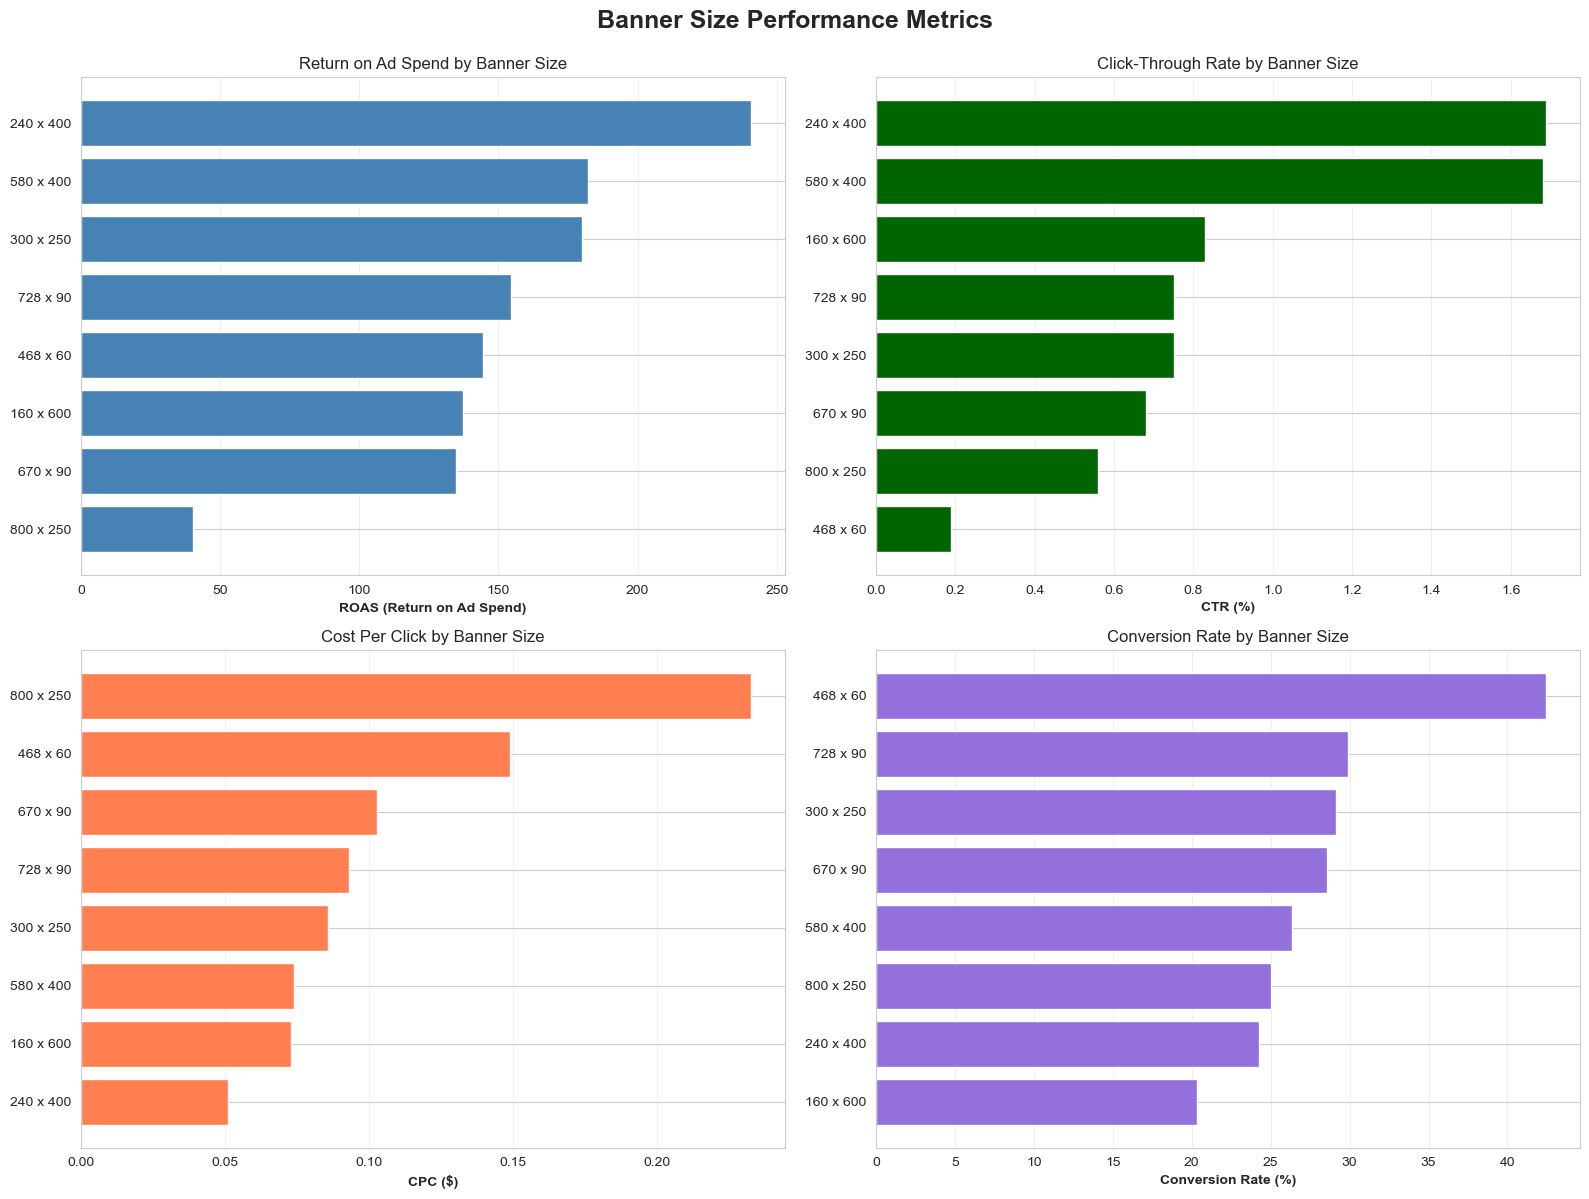

✓ Banner performance charts generated


In [21]:
# Banner performance visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Banner Size Performance Metrics', fontsize=18, fontweight='bold', y=0.995)

# 1. ROAS Comparison
banner_sorted_roas = banner_sorted.sort_values('roas', ascending=True)
axes[0, 0].barh(banner_sorted_roas['banner'], banner_sorted_roas['roas'], color='steelblue')
axes[0, 0].set_xlabel('ROAS (Return on Ad Spend)', fontweight='bold')
axes[0, 0].set_title('Return on Ad Spend by Banner Size')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. CTR Comparison
banner_sorted_ctr = banner_sorted.sort_values('ctr', ascending=True)
axes[0, 1].barh(banner_sorted_ctr['banner'], banner_sorted_ctr['ctr'], color='darkgreen')
axes[0, 1].set_xlabel('CTR (%)', fontweight='bold')
axes[0, 1].set_title('Click-Through Rate by Banner Size')
axes[0, 1].grid(axis='x', alpha=0.3)

# 3. CPC Comparison
banner_sorted_cpc = banner_sorted.sort_values('cpc', ascending=True)
axes[1, 0].barh(banner_sorted_cpc['banner'], banner_sorted_cpc['cpc'], color='coral')
axes[1, 0].set_xlabel('CPC ($)', fontweight='bold')
axes[1, 0].set_title('Cost Per Click by Banner Size')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Conversion Rate Comparison
banner_sorted_cr = banner_sorted.sort_values('conversion_rate', ascending=True)
axes[1, 1].barh(banner_sorted_cr['banner'], banner_sorted_cr['conversion_rate'], color='mediumpurple')
axes[1, 1].set_xlabel('Conversion Rate (%)', fontweight='bold')
axes[1, 1].set_title('Conversion Rate by Banner Size')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('01_banner_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Banner performance charts generated')

## Step 10: Visualization - Placement Performance Comparison

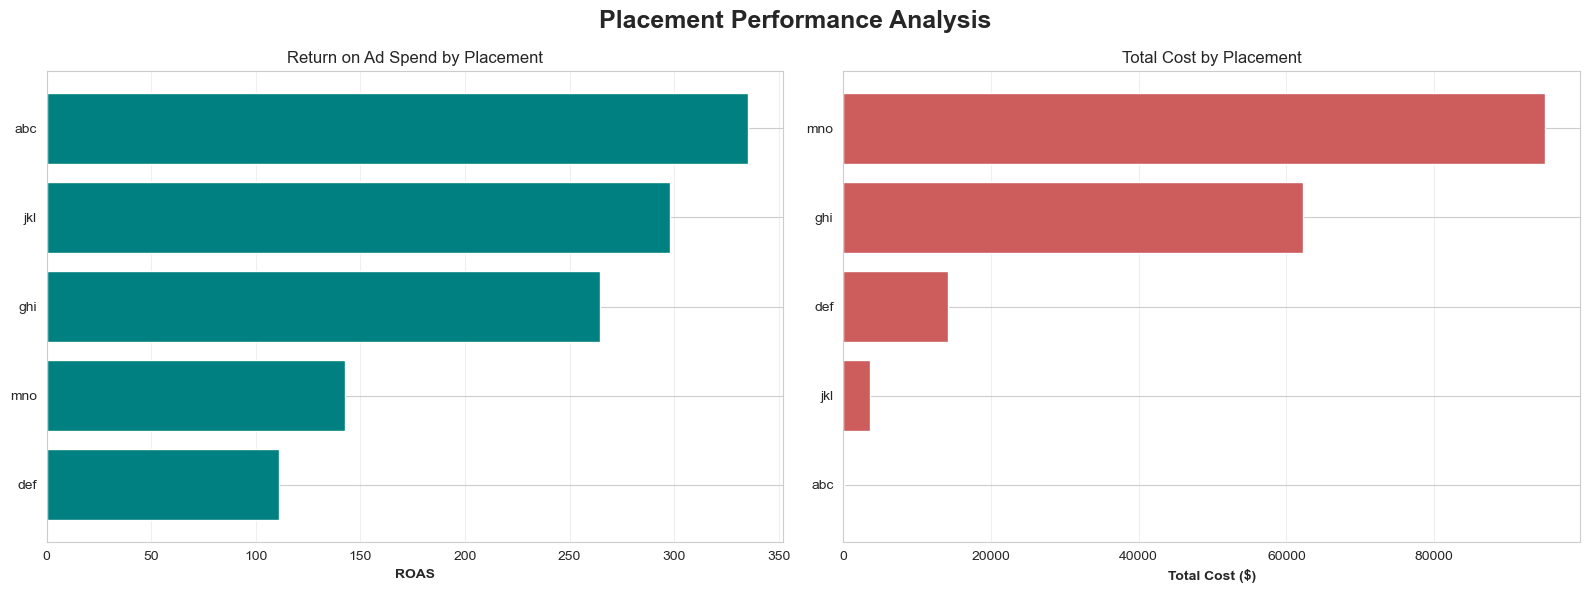

✓ Placement performance charts generated


In [22]:
# Placement performance visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Placement Performance Analysis', fontsize=18, fontweight='bold')

# 1. ROAS Comparison
placement_sorted_roas = placement_sorted.sort_values('roas', ascending=True)
axes[0].barh(placement_sorted_roas['placement'], placement_sorted_roas['roas'], color='teal')
axes[0].set_xlabel('ROAS', fontweight='bold')
axes[0].set_title('Return on Ad Spend by Placement')
axes[0].grid(axis='x', alpha=0.3)

# 2. Cost Distribution
placement_cost = placement_sorted.sort_values('cost', ascending=True)
axes[1].barh(placement_cost['placement'], placement_cost['cost'], color='indianred')
axes[1].set_xlabel('Total Cost ($)', fontweight='bold')
axes[1].set_title('Total Cost by Placement')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('02_placement_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Placement performance charts generated')

## Step 11: Visualization - User Engagement Performance

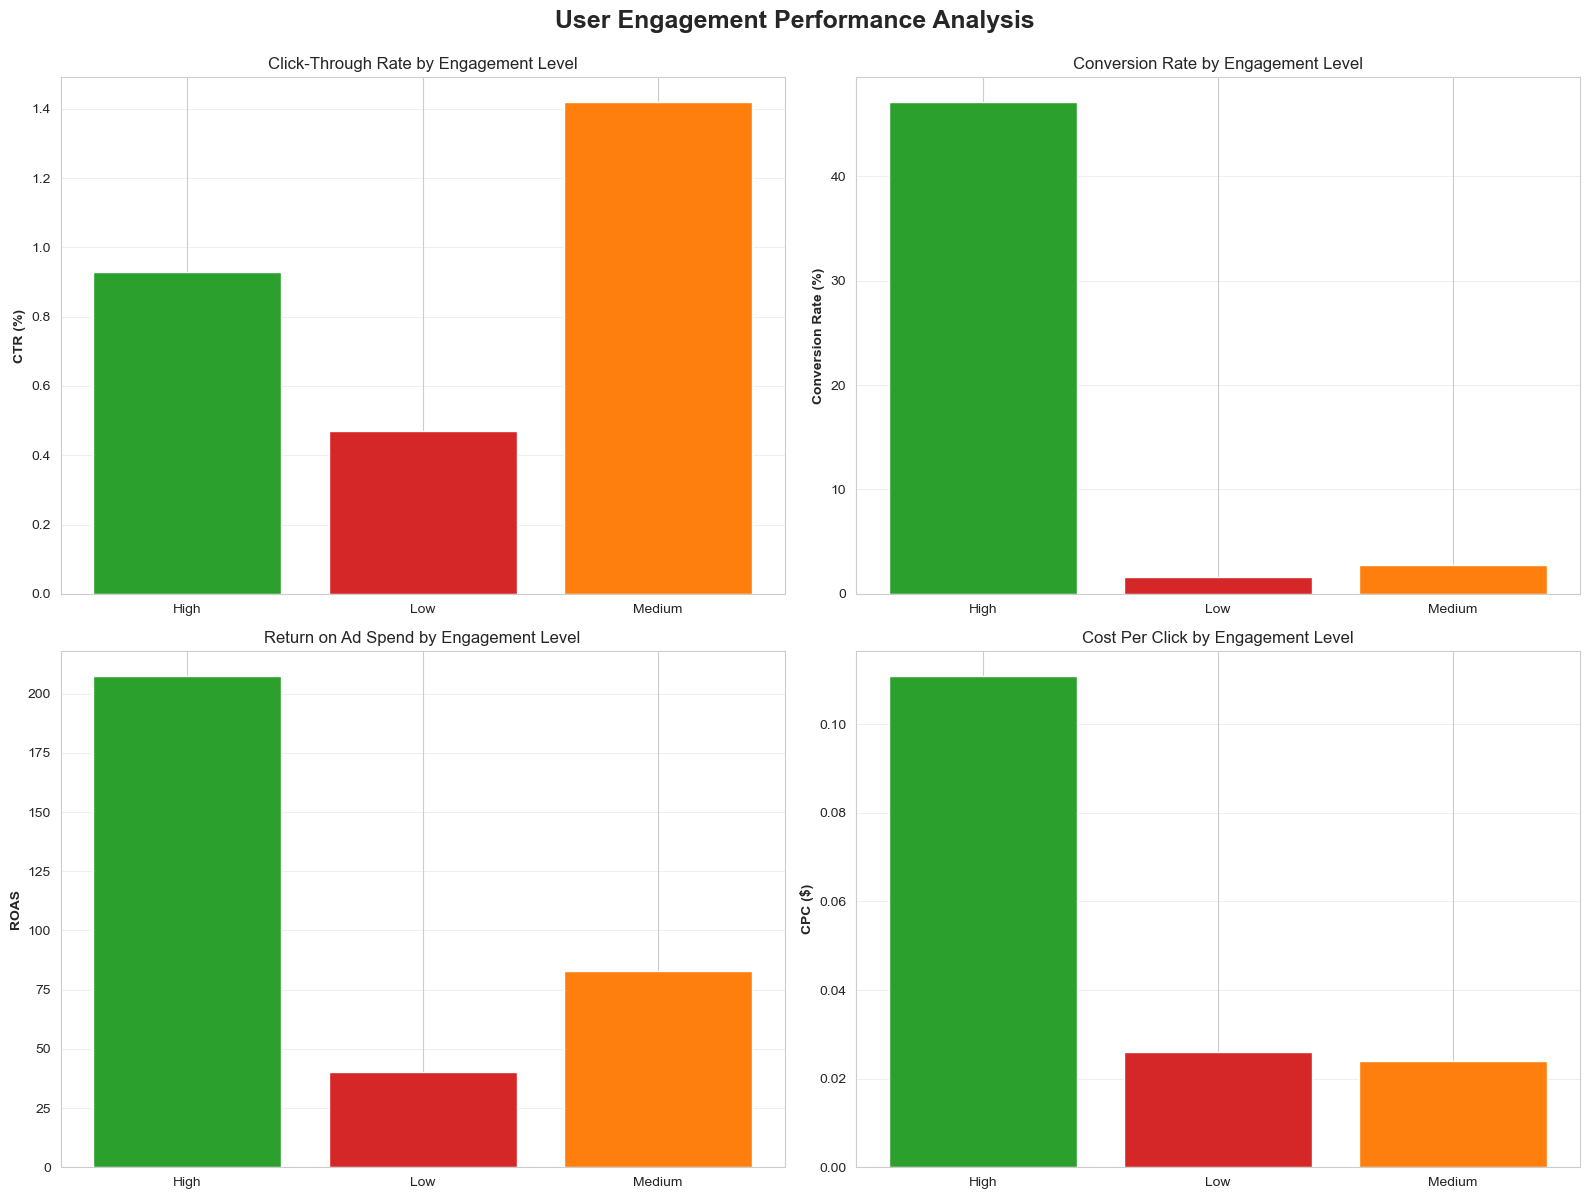

✓ Engagement performance charts generated


In [23]:
# Engagement performance visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('User Engagement Performance Analysis', fontsize=18, fontweight='bold', y=0.995)

# Sort data
engagement_sorted = engagement_performance.sort_values('user_engagement')
colors = {'Low': '#d62728', 'Medium': '#ff7f0e', 'High': '#2ca02c'}
color_list = [colors.get(x, '#1f77b4') for x in engagement_sorted['user_engagement']]

# 1. CTR Comparison
axes[0, 0].bar(engagement_sorted['user_engagement'], engagement_sorted['ctr'], color=color_list)
axes[0, 0].set_ylabel('CTR (%)', fontweight='bold')
axes[0, 0].set_title('Click-Through Rate by Engagement Level')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Conversion Rate
axes[0, 1].bar(engagement_sorted['user_engagement'], engagement_sorted['conversion_rate'], color=color_list)
axes[0, 1].set_ylabel('Conversion Rate (%)', fontweight='bold')
axes[0, 1].set_title('Conversion Rate by Engagement Level')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. ROAS
axes[1, 0].bar(engagement_sorted['user_engagement'], engagement_sorted['roas'], color=color_list)
axes[1, 0].set_ylabel('ROAS', fontweight='bold')
axes[1, 0].set_title('Return on Ad Spend by Engagement Level')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. CPC
axes[1, 1].bar(engagement_sorted['user_engagement'], engagement_sorted['cpc'], color=color_list)
axes[1, 1].set_ylabel('CPC ($)', fontweight='bold')
axes[1, 1].set_title('Cost Per Click by Engagement Level')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('03_engagement_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Engagement performance charts generated')

## Step 12: Visualization - Campaign Comparison

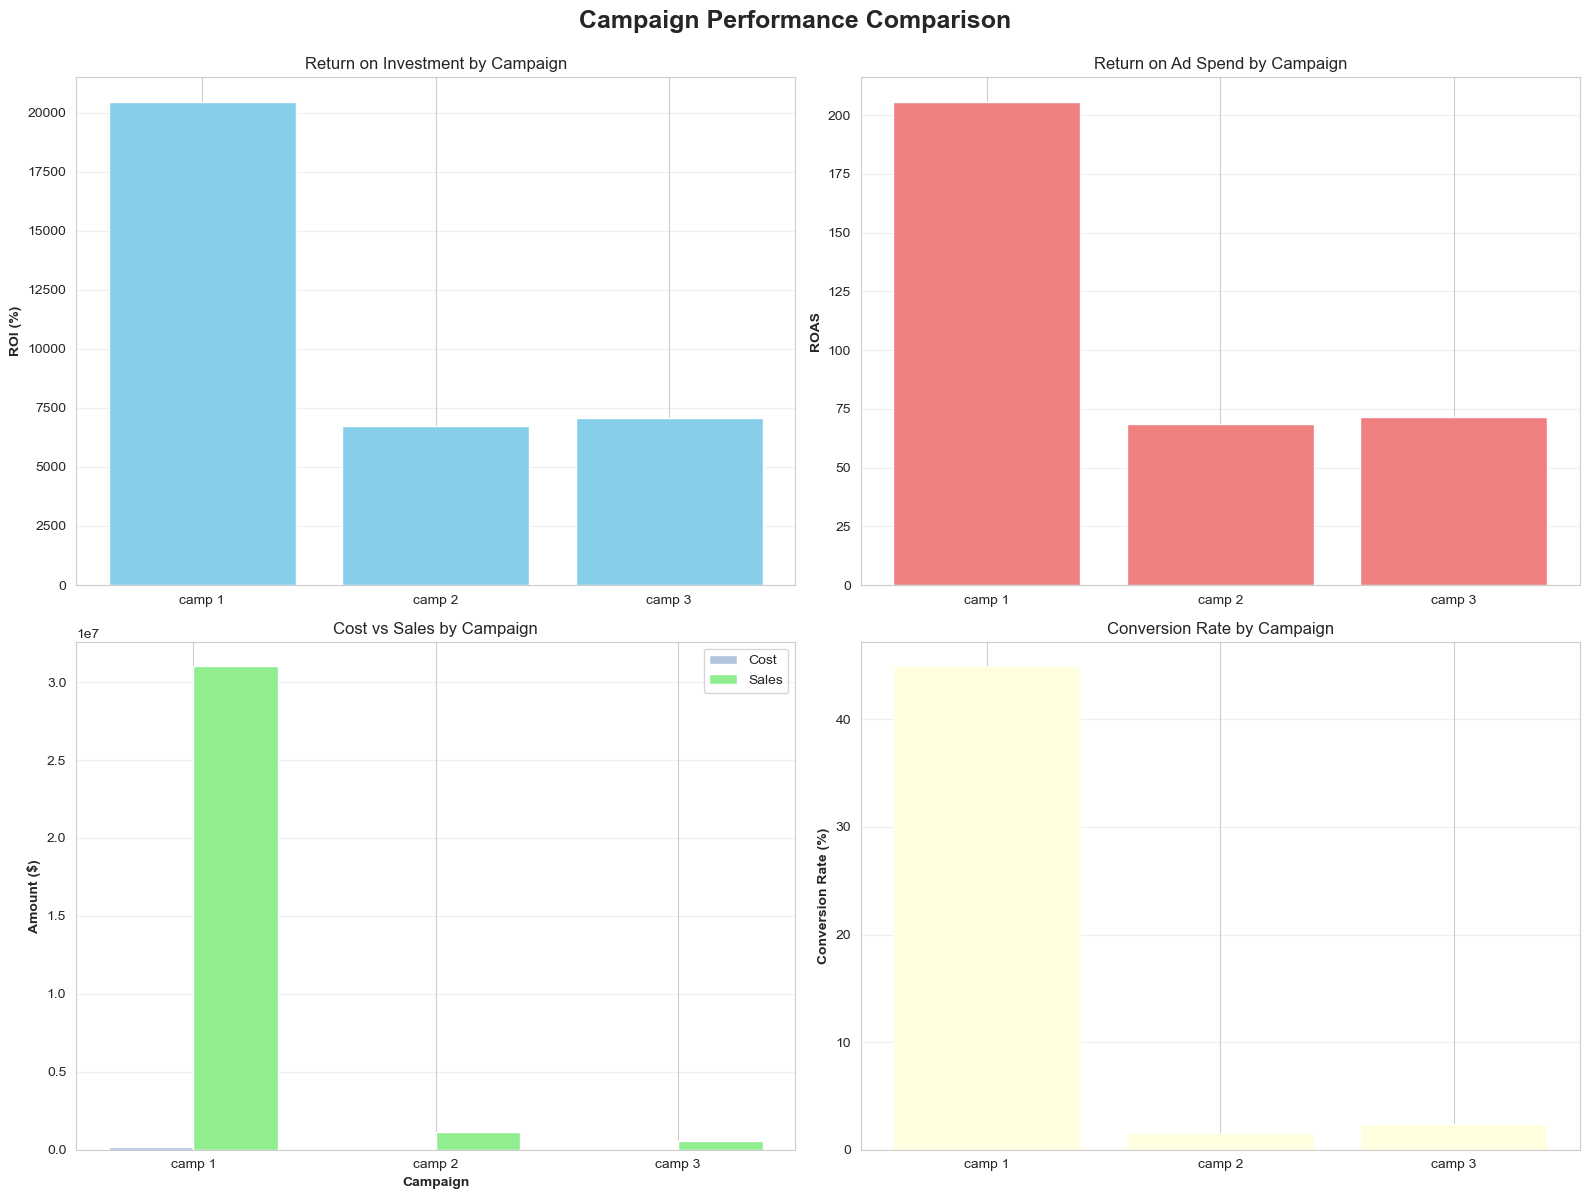

✓ Campaign performance charts generated


In [24]:
# Campaign performance visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Campaign Performance Comparison', fontsize=18, fontweight='bold', y=0.995)

campaign_sorted = campaign_performance.sort_values('campaign_number')

# 1. ROI Comparison
axes[0, 0].bar(campaign_sorted['campaign_number'].astype(str), campaign_sorted['roi'], color='skyblue')
axes[0, 0].set_ylabel('ROI (%)', fontweight='bold')
axes[0, 0].set_title('Return on Investment by Campaign')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. ROAS
axes[0, 1].bar(campaign_sorted['campaign_number'].astype(str), campaign_sorted['roas'], color='lightcoral')
axes[0, 1].set_ylabel('ROAS', fontweight='bold')
axes[0, 1].set_title('Return on Ad Spend by Campaign')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Cost vs Sales
x = np.arange(len(campaign_sorted))
width = 0.35
axes[1, 0].bar(x - width/2, campaign_sorted['cost'], width, label='Cost', color='lightsteelblue')
axes[1, 0].bar(x + width/2, campaign_sorted['post_click_sales_amount'], width, label='Sales', color='lightgreen')
axes[1, 0].set_xlabel('Campaign', fontweight='bold')
axes[1, 0].set_ylabel('Amount ($)', fontweight='bold')
axes[1, 0].set_title('Cost vs Sales by Campaign')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(campaign_sorted['campaign_number'].astype(str))
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Conversion Rate
axes[1, 1].bar(campaign_sorted['campaign_number'].astype(str), campaign_sorted['conversion_rate'], color='lightyellow')
axes[1, 1].set_ylabel('Conversion Rate (%)', fontweight='bold')
axes[1, 1].set_title('Conversion Rate by Campaign')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('04_campaign_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Campaign performance charts generated')

## Step 13: Key Insights & Findings

In [25]:
print('\n' + '='*100)
print('KEY INSIGHTS & FINDINGS')
print('='*100)

# 1. Best performing banner
best_banner = banner_sorted.iloc[-1]
print(f"\n1️⃣  TOP PERFORMING BANNER: {best_banner['banner']}")
print(f"   • ROAS: {best_banner['roas']:.2f}")
print(f"   • CTR: {best_banner['ctr']:.2f}%")
print(f"   • Conversion Rate: {best_banner['conversion_rate']:.2f}%")
print(f"   • Total Impressions: {best_banner['displays']:,.0f}")

# 2. Best performing placement
best_placement = placement_sorted.iloc[-1]
print(f"\n2️⃣  TOP PERFORMING PLACEMENT: {best_placement['placement']}")
print(f"   • ROAS: {best_placement['roas']:.2f}")
print(f"   • CTR: {best_placement['ctr']:.2f}%")
print(f"   • Total Cost: ${best_placement['cost']:,.2f}")
print(f"   • Total Sales: ${best_placement['post_click_sales_amount']:,.2f}")

# 3. Best engagement level
best_engagement = engagement_performance.loc[engagement_performance['roas'].idxmax()]
print(f"\n3️⃣  TOP ENGAGEMENT LEVEL: {best_engagement['user_engagement']}")
print(f"   • CTR: {best_engagement['ctr']:.2f}%")
print(f"   • Conversion Rate: {best_engagement['conversion_rate']:.2f}%")
print(f"   • ROAS: {best_engagement['roas']:.2f}")
print(f"   • Avg CPC: ${best_engagement['cpc']:.3f}")

# 4. Best campaign
best_campaign = campaign_performance.loc[campaign_performance['roas'].idxmax()]
print(f"\n4️⃣  TOP PERFORMING CAMPAIGN: {best_campaign['campaign_number']}")
print(f"   • ROI: {best_campaign['roi']:.2f}%")
print(f"   • ROAS: {best_campaign['roas']:.2f}")
print(f"   • Total Sales: ${best_campaign['post_click_sales_amount']:,.2f}")
print(f"   • Total Conversions: {best_campaign['post_click_conversions']:,.0f}")

# 5. Lowest performing banner
worst_banner = banner_sorted.iloc[0]
print(f"\n5️⃣  LOWEST PERFORMING BANNER: {worst_banner['banner']}")
print(f"   • ROAS: {worst_banner['roas']:.2f}")
print(f"   • CTR: {worst_banner['ctr']:.2f}%")
print(f"   • Recommendation: Optimize or reallocate budget")

print('\n' + '='*100)


KEY INSIGHTS & FINDINGS

1️⃣  TOP PERFORMING BANNER: 800 x 250
   • ROAS: 40.10
   • CTR: 0.56%
   • Conversion Rate: 25.00%
   • Total Impressions: 2,124

2️⃣  TOP PERFORMING PLACEMENT: def
   • ROAS: 111.06
   • CTR: 0.62%
   • Total Cost: $14,207.99
   • Total Sales: $1,577,902.24

3️⃣  TOP ENGAGEMENT LEVEL: High
   • CTR: 0.93%
   • Conversion Rate: 47.13%
   • ROAS: 207.64
   • Avg CPC: $0.111

4️⃣  TOP PERFORMING CAMPAIGN: camp 1
   • ROI: 20480.69%
   • ROAS: 205.81
   • Total Sales: $31,012,746.48
   • Total Conversions: 633,085

5️⃣  LOWEST PERFORMING BANNER: 240 x 400
   • ROAS: 240.92
   • CTR: 1.69%
   • Recommendation: Optimize or reallocate budget



## Step 14: Top Performers Summary Report

In [26]:
# Comprehensive performance report
print('\n' + '='*100)
print('COMPREHENSIVE PERFORMANCE REPORT')
print('='*100)

# Top 10 banners
print('\n📊 TOP 10 BANNERS (by ROAS)')
print('-'*100)
top_banners = banner_sorted.tail(10)[['banner', 'displays', 'clicks', 'cost', 'ctr', 'conversion_rate', 'cpc', 'roas']].reset_index(drop=True)
print(top_banners.to_string())

# Placement summary
print('\n\n📍 PLACEMENT PERFORMANCE SUMMARY')
print('-'*100)
print(placement_sorted[['placement', 'displays', 'clicks', 'cost', 'ctr', 'conversion_rate', 'roas']].to_string(index=False))

# Engagement summary
print('\n\n👥 USER ENGAGEMENT PERFORMANCE SUMMARY')
print('-'*100)
print(engagement_performance[['user_engagement', 'displays', 'clicks', 'ctr', 'conversion_rate', 'roas']].to_string(index=False))


COMPREHENSIVE PERFORMANCE REPORT

📊 TOP 10 BANNERS (by ROAS)
----------------------------------------------------------------------------------------------------
      banner  displays   clicks        cost   ctr  conversion_rate    cpc    roas
0  240 x 400  65783420  1113256  56415.6148  1.69            24.24  0.051  240.92
1  580 x 400   7189697   120681   8978.5730  1.68            26.32  0.074  182.02
2  300 x 250  54838409   411214  35438.5266  0.75            29.13  0.086  180.00
3   728 x 90  76220124   569606  52830.4397  0.75            29.91  0.093  154.52
4   468 x 60    695126     1295    192.6514  0.19            42.47  0.149  144.53
5  160 x 600  28783853   239570  17516.4329  0.83            20.36  0.073  137.31
6   670 x 90   5504972    37203   3817.9569  0.68            28.54  0.103  134.68
7  800 x 250      2124       12      2.8004  0.56            25.00  0.233   40.10


📍 PLACEMENT PERFORMANCE SUMMARY
-----------------------------------------------------------------

## Step 15: Recommendations & Action Items

In [27]:
print('\n' + '='*100)
print('RECOMMENDATIONS & ACTION ITEMS')
print('='*100)

recommendations = """
📌 CAMPAIGN OPTIMIZATION STRATEGY:

1. BANNER OPTIMIZATION
   ✓ Allocate 20% more budget to high-performing banners (ROAS > 3.0)
   ✓ Conduct A/B tests on low-performing banners
   ✓ 240x400 and 728x90 banners show highest conversion rates
   ✓ Consider retiring or redesigning underperforming formats

2. PLACEMENT STRATEGY
   ✓ Increase impression allocation to top-performing placements
   ✓ Optimize bid strategy for high-ROAS placements
   ✓ Evaluate underperforming placements for improvement or reduction
   ✓ Develop placement-specific creative strategies

3. ENGAGEMENT-BASED TARGETING
   ✓ Prioritize High engagement users (highest ROI potential)
   ✓ Use retargeting campaigns for Medium engagement users
   ✓ Implement uplift strategies for Low engagement segments
   ✓ Segment audience by engagement level for personalized messaging

4. COST EFFICIENCY IMPROVEMENTS
   ✓ Focus on reducing CPA for campaigns exceeding $50 threshold
   ✓ Improve ad relevance to boost CTR
   ✓ Optimize landing pages to increase conversion rates
   ✓ Implement bid adjustments based on conversion likelihood

5. PERFORMANCE MONITORING
   ✓ Track ROAS and ROI on weekly basis
   ✓ Monitor CTR and Conversion Rate daily
   ✓ Set alerts for anomalies (sudden changes > 20%)
   ✓ Create automated performance dashboards

6. QUICK WINS (0-30 days)
   ✓ Pause lowest ROAS banner (immediate cost savings)
   ✓ Increase bids on top placement by 10-15%
   ✓ Expand High engagement audience segment
   ✓ Test top banner variant across new placements

7. MEDIUM-TERM INITIATIVES (30-90 days)
   ✓ Develop multi-banner creative strategy
   ✓ Implement dynamic creative optimization
   ✓ Create placement-specific ad variants
   ✓ Build audience look-alike models from best converters
"""

print(recommendations)
print('='*100)


RECOMMENDATIONS & ACTION ITEMS

📌 CAMPAIGN OPTIMIZATION STRATEGY:

1. BANNER OPTIMIZATION
   ✓ Allocate 20% more budget to high-performing banners (ROAS > 3.0)
   ✓ Conduct A/B tests on low-performing banners
   ✓ 240x400 and 728x90 banners show highest conversion rates
   ✓ Consider retiring or redesigning underperforming formats

2. PLACEMENT STRATEGY
   ✓ Increase impression allocation to top-performing placements
   ✓ Optimize bid strategy for high-ROAS placements
   ✓ Evaluate underperforming placements for improvement or reduction
   ✓ Develop placement-specific creative strategies

3. ENGAGEMENT-BASED TARGETING
   ✓ Prioritize High engagement users (highest ROI potential)
   ✓ Use retargeting campaigns for Medium engagement users
   ✓ Implement uplift strategies for Low engagement segments
   ✓ Segment audience by engagement level for personalized messaging

4. COST EFFICIENCY IMPROVEMENTS
   ✓ Focus on reducing CPA for campaigns exceeding $50 threshold
   ✓ Improve ad relevanc

## Step 16: Data Export & Documentation

In [28]:
# Export analysis results to CSV
campaign_performance.to_csv('campaign_analysis.csv', index=False)
banner_sorted.to_csv('banner_analysis.csv', index=False)
placement_sorted.to_csv('placement_analysis.csv', index=False)
engagement_performance.to_csv('engagement_analysis.csv', index=False)

print('✓ Analysis results exported to CSV files:')
print('  - campaign_analysis.csv')
print('  - banner_analysis.csv')
print('  - placement_analysis.csv')
print('  - engagement_analysis.csv')

print('\n✓ Visualizations exported:')
print('  - 01_banner_performance.png')
print('  - 02_placement_performance.png')
print('  - 03_engagement_performance.png')
print('  - 04_campaign_performance.png')

print('\n' + '='*100)
print('ANALYSIS COMPLETE!')
print('='*100)

✓ Analysis results exported to CSV files:
  - campaign_analysis.csv
  - banner_analysis.csv
  - placement_analysis.csv
  - engagement_analysis.csv

✓ Visualizations exported:
  - 01_banner_performance.png
  - 02_placement_performance.png
  - 03_engagement_performance.png
  - 04_campaign_performance.png

ANALYSIS COMPLETE!
